## PLOT RETRIEVAL RESULTS

# Import some useful stuff, define TP functions

In [ ]:
import os

from scipy.interpolate import PchipInterpolator
import petitRADTRANS.physical_constants as cst
import matplotlib.pyplot as plt
import numpy as np
import corner

from petitRADTRANS.radtrans import Radtrans
from astropy.io import fits
import pymultinest

import pickle
from convolve import rotate,rot_int_cmj,broaden

In [4]:
#Check live points mid-run
prefix = "Results_Fe/"
points = np.loadtxt(prefix+"phys_live.points")
for point in points.T:
    print("Mean :" + str(np.median(point)) + " Std:" + str(np.std(point)))

Mean :223.29133192550128 Std:3.8811605177178334
Mean :53.607561474704994 Std:2.199483406025008
Mean :-2.01768857673579 Std:0.9280802003248017
Mean :1516.2507179717686 Std:577.749052469641
Mean :4818.587338139063 Std:655.037650116395
Mean :-2.329480176121287 Std:1.1635252412844053
Mean :4.657657635656864 Std:1.8072560744004527
Mean :-486951.6635749301 Std:0.2561876651507012
Mean :1.0 Std:0.0


In [5]:
with open(prefix+"config.pkl", "rb") as f:
    run_parameters = pickle.load(f)

parameters = run_parameters["priors"]
data_dic   = run_parameters["data"]
config     = run_parameters["config"]

In [ ]:
#Temperature profile functions
def my_t_profile(pressures, temperature_points, pressure_points, **kwargs):
    TP = PchipInterpolator(np.log(pressure_points), temperature_points)
    temperatures = TP(np.log(pressures))
    mask_low = pressures < pressure_points[0]
    temperatures[mask_low] = temperature_points[0]
    return temperatures

def two_point_profile(pressures, T_top, T_bot, P_top, P_bot, **kwargs):
    logP = np.log10(pressures)
    logPt, logPb = np.log10(P_top), np.log10(P_bot)
    slope = (T_bot - T_top) / (logPb - logPt)
    temperatures = T_top + slope * (logP - logPt)
    temperatures = np.where(pressures <= P_top, T_top, temperatures)
    temperatures = np.where(pressures >= P_bot, T_bot, temperatures)
    return temperatures

In [68]:
h     = 6.62606957e-34 # [J.s]
c0     = 2.99792458e8   # [m/s]
k     = 1.38e-23       # [m^2.kg/s^2/K]

#Black-Body for creating CCF template
def bb(wav, temp, freq=False):                       
  """
  Function to calculate the blackbody flux for a given temperature
  wav  - wavelength in m 
  temp - Temperature in K
  freq -optional- Boolean, whether to interpret wav 
          as a frequency in Hz [default=False]

  Output: Flux in ergs / sec / cm^2 / cm (ergs / sec / cm^2 / Hz if freq=True).
  """
  if freq==True:
    c1 = 2*h*wav**3/c**2
    c2 = h*wav/(k*temp)          
  else:
    c1 = 2*h*c0**2/wav**5
    c2 = h*c0/(wav*k*temp)

  amp = c1/((np.exp(c2)-1))         #W/sr/m2/m (W/s/m2/Hz if freq=True)
  amp *= 1e1 * (np.pi)
  if freq:
    amp*=1e2
  return amp

# Fix for missprinted values if necessary...

Sometimes multinest missprints values with very large exponents. This likely means something is wrong with the retrieval, but it can still be usefull to load the results and/or live points to understand what is happening, so this can be used to reformat those files properly.

In [ ]:
import re
prefix = "../Results/"
#filename to change, typically one of: post_equal_weights.dat, .txt or phys_live.points
filename = prefix + "phys_live.points"
with open(filename) as f: 
    lines = f.readlines()

fixed = []
for line in lines:
    fixed.append(re.sub(r'(\d)-(\d{2,3})', r'\1E-\2', line))

with open(filename, "w") as f:
    f.writelines(fixed)

# Corner Plots

In [7]:
labels = list(parameters.keys())
n_params = len(labels)

analyzer = pymultinest.Analyzer(n_params, outputfiles_basename=prefix)

data = analyzer.get_data()
samples = analyzer.get_equal_weighted_posterior()[:, :-1]
stats = analyzer.get_stats()
marginals = {labels[X]: stats["marginals"][X] for X in range(len(labels))}

weights = data[:,0]
params  = data[:,2:]

  analysing data from Results_Fe/.txt


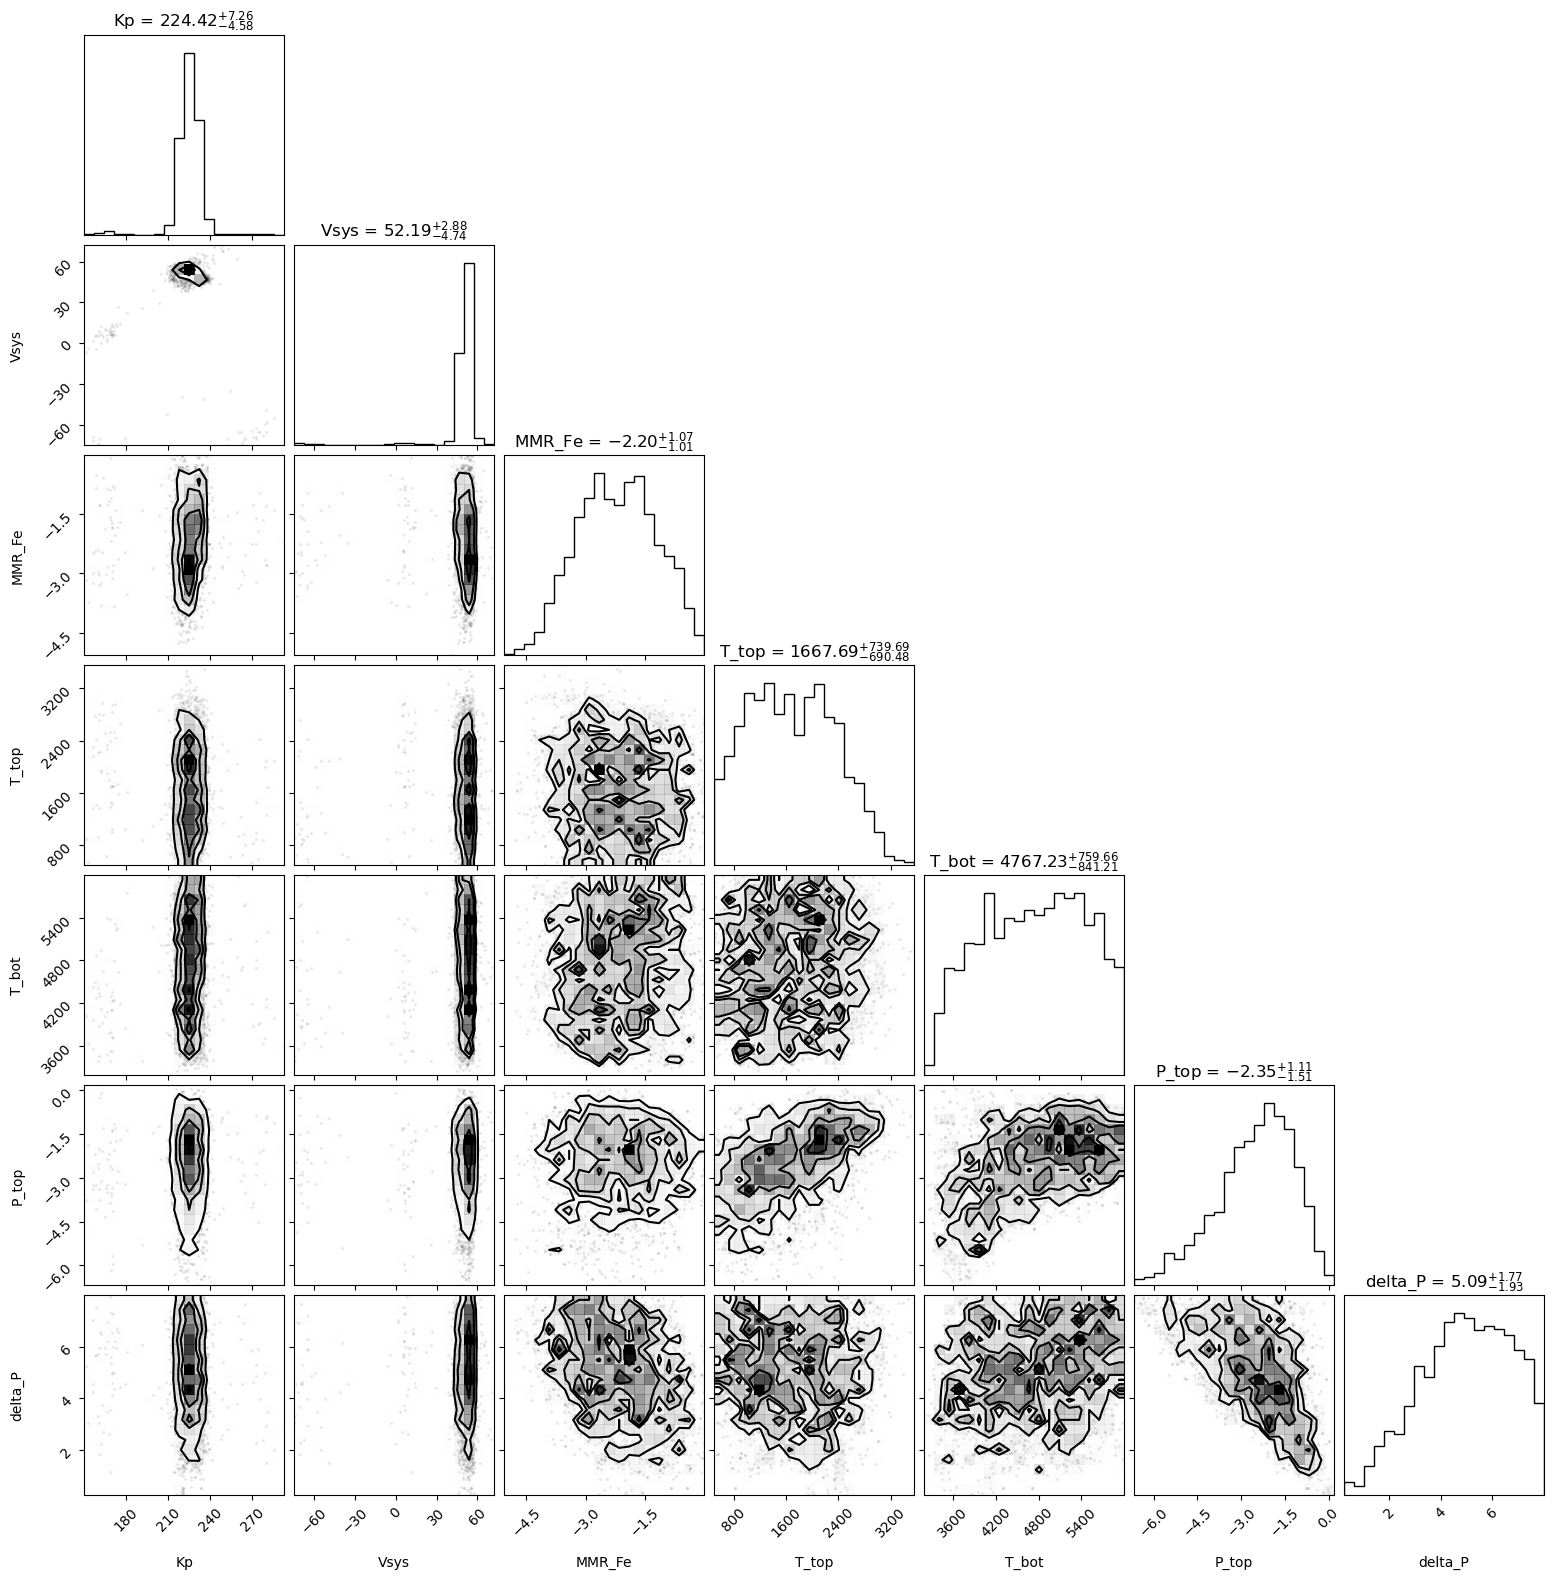

In [8]:
figure = corner.corner(
    samples,
    labels=labels,
    show_titles=True
)

plt.show()

# Plot Temperature Profile

In [9]:
pressures = np.logspace(config["p_minbar"],config["p_maxbar"],config["n_pressure"])
if config["temperature_profile"] == "parametric":
    pressure_points = config["pressure_points"]
    temperature_points = np.array([maginals["T"+str(X+1)]["median"] for X in range(len(pressure_points))])
    temperatures = my_t_profile(pressures, temperature_points, pressure_points)
    TP_low_1sigma = my_t_profile(pressures,np.array([maginals["T"+str(X+1)]["1sigma"][0] for X in range(len(pressure_points))]),pressure_points)
    TP_high_1sigma = my_t_profile(pressures,np.array([maginals["T"+str(X+1)]["1sigma"][1] for X in range(len(pressure_points))]),pressure_points)
    TP_low_3sigma = my_t_profile(pressures,np.array([maginals["T"+str(X+1)]["3sigma"][0] for X in range(len(pressure_points))]),pressure_points)
    TP_high_3sigma = my_t_profile(pressures,np.array([maginals["T"+str(X+1)]["3sigma"][1] for X in range(len(pressure_points))]),pressure_points)
    
elif config["temperature_profile"] == "two_point":
    T_top, T_bot, P_top, delta_P = marginals["T_top"], marginals["T_bot"], marginals["P_top"], marginals["delta_P"]
    temperatures = two_point_profile(pressures, T_top['median'], T_bot["median"], 
                    10**P_top["median"], 10**(P_top["median"]+delta_P["median"]))

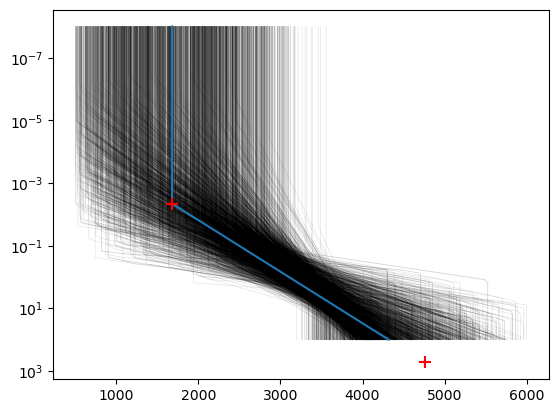

In [10]:
fig, ax = plt.subplots(1,1)
if config["temperature_profile"] == "two_point":
    for point in samples:
        TP_point = two_point_profile(pressures, point[3], point[4], 10**point[5], 10**(point[5]+point[6]))
        ax.semilogy(TP_point, pressures, c="k", alpha=0.1, lw=0.5,zorder=1)
    ax.scatter( (T_top['median'], T_bot["median"]), 
            (10**P_top["median"],10**(P_top["median"]+delta_P["median"])), marker="+",s=75, c="red",zorder=3)
elif config["temperature_profile"] == "parametric":
    ax.fill_betweenx(pressures,TP_low_1sigma,TP_high_1sigma, color="C0", alpha=0.5,zorder=0)
    ax.fill_betweenx(pressures,TP_low_3sigma,TP_high_3sigma, color="C0", alpha=0.5,zorder=1)
    ax.scatter(temperature_points, pressure_points, marker="+",s=75,zorder=3)
ax.semilogy(temperatures, pressures, zorder=2)
ax.yaxis.set_inverted(True)

# Plot Spectrum / Contribution Function

In [11]:
lambdas = config["lambdas"][np.nonzero(config["lambdas"])]*1e-3 #Wavelength boundaries in micron
radtrans = Radtrans(
    # Radtrans parameters
    pressures=pressures, 
    line_species=list(config["line_species"].keys()),  
    rayleigh_species=['H2', 'He'],
    gas_continuum_contributors=['H2--H2', 'H2--He'],
    wavelength_boundaries=[0.995*np.min(lambdas),1.005*np.max(lambdas)],
    line_opacity_mode='lbl',
    line_by_line_opacity_sampling=4,
    scattering_in_emission = True,)

Loading Radtrans opacities...
 Loading line opacities of species 'Fe' from file '/group/exoplanetes/petitRADTRANS/input_data/opacities/lines/line_by_line/Fe/56Fe/56Fe__Kurucz.R1e6_0.3-28mu.xsec.petitRADTRANS.h5'... Done.
 Successfully loaded all line opacities
 Loading CIA opacities for H2--H2 from file '/group/exoplanetes/petitRADTRANS/input_data/opacities/continuum/collision_induced_absorptions/H2--H2/H2--H2-NatAbund/H2--H2-NatAbund__BoRi.R831_0.6-250mu.ciatable.petitRADTRANS.h5'... Done.
 Loading CIA opacities for H2--He from file '/group/exoplanetes/petitRADTRANS/input_data/opacities/continuum/collision_induced_absorptions/H2--He/H2--He-NatAbund/H2--He-NatAbund__BoRi.DeltaWavenumber2_0.5-500mu.ciatable.petitRADTRANS.h5'... Done.
 Successfully loaded all CIA opacities
Successfully loaded all opacities


In [13]:
#Prepare abundances from posteriors
Z,MW_sum = 0,0
mass_fractions = {}
for key in list(config["line_species"].keys()):
    MMR = 10**marginals["MMR_"+key]["median"]
    Z += MMR
    MW_sum += MMR / config["line_species"][key]
    mass_frac = {key: MMR *np.ones_like(temperatures)}
    mass_fractions.update(mass_frac)

MMR_H2 = (1.0-Z)*(1-config["HHe_ratio"])
MMR_He = config["HHe_ratio"]*(1.0-Z)
MW_sum += MMR_H2/2.0 + MMR_He/4.0
MMW = 1.0/MW_sum*np.ones_like(temperatures)
mass_fractions.update(H2= MMR_H2*np.ones_like(temperatures), He= MMR_He*np.ones_like(temperatures))
print([(key,mass_fractions[key][0]) for key in mass_fractions])
print("MMW : " + str(1/MW_sum))

[('Fe', 0.006343686878372745), ('H2', 0.7204008270131798), ('He', 0.2732554861084475)]
MMW : 2.3330277408425926


In [14]:
#Compute model
wavelengths, flux, additional_outputs = radtrans.calculate_flux(
    temperatures= temperatures,
    mass_fractions=mass_fractions,
    mean_molar_masses=MMW,
    reference_gravity=config["gravity_SI"]*100,
    frequencies_to_wavelengths=True,
    return_contribution=True
)
try:
    vrot = config["Vrot"]
except:
    vrot = marginals["Vrot"]["median"]

In [ ]:
try:
    vrot = config["Vrot"]
except:
    vrot = marginals["Vrot"]["median"]

if config["winds"]:
    wl_conv, flux_conv = rotate(wavelengths,flux,vrot,0)
else:
    flux_broad = rot_int_cmj(wavelengths, flux, vrot)
    flux_conv = broaden(wavelengths,flux_broad,config["sigma"])
    wl_conv = wavelengths

In [ ]:
#Star from pheonix file
wav_pheonix = fits.open("WAVE_PHOENIX-ACES-AGSS-COND-2011.fits")
star_pheonix = fits.open("lte06500-4.00-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits")

wl_pheonix = wav_pheonix[0].data / 1e8 #[cm]
I_pheonix = star_pheonix[0].data
I_broadened = rot_int_cmj(wl_pheonix,I_pheonix,config["vsini"])

star_radius = config["Rs_Rsun"]*cst.r_sun           #[cm]
planet_radius = config["radius_RJ"]*cst.r_jup_mean     #[cm]
system_distance = config["system_distance"]*1e5     #[cm]

I_scaled = I_broadened*(star_radius/system_distance)**2

#Star from Blackbody
T_star = 6540
star_bb = bb(wl_conv*1e-2,T_star)
star_bb_obs = star_bb * (star_radius/system_distance)**2

In [ ]:
#Scale spectra and wavelengths
star_bb_obs = star_bb * (star_radius/system_distance)**2
flux_obs   = flux_conv * (planet_radius/system_distance)**2
flux_final = flux_obs / np.interp(wl_conv, wl_pheonix, I_scaled)
flux_ccf   = flux_obs / star_bb_obs
wl_conv *= 1e4

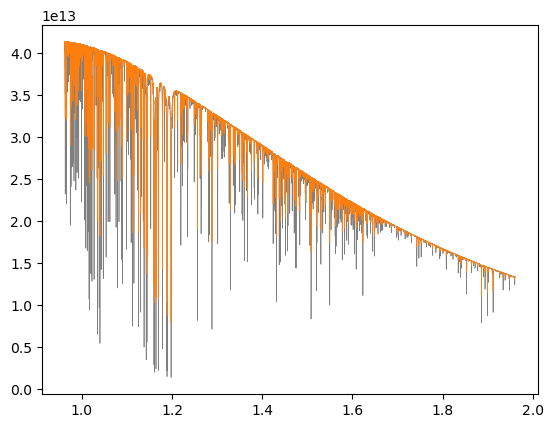

In [ ]:
#Plot the planet on its own
plt.plot(wavelengths*1e4,flux,c="k",alpha=0.5,lw=0.5)
plt.plot(wl_conv,flux_conv,c="C1",lw=0.5)

Text(0.5, 0, 'Wavelength ($\\mu$m)')

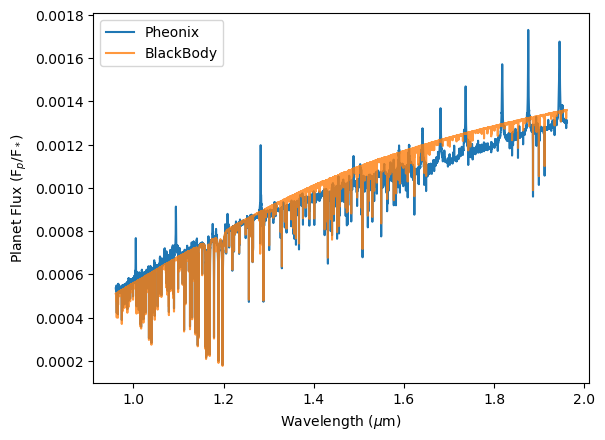

In [75]:
# Plot the model normalised by the stellar spectrum 
# (the pheonix star hasnt been shifted like in full retrieval but it gives an idea)
plt.plot(wl_conv, flux_final, label="Pheonix")
plt.plot(wl_conv, flux_ccf,alpha=0.8,label="BlackBody")
plt.legend()
plt.ylabel("Planet Flux (F$_p$/F$_*$)")
plt.xlabel("Wavelength ($\mu$m)")

Text(0.5, 1.0, 'Emission contribution function')

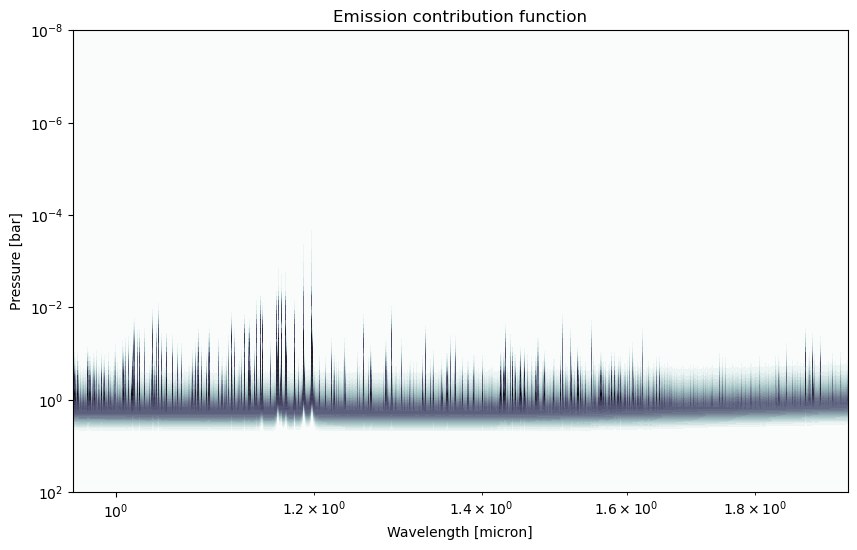

In [65]:
# Plot contribution function
wavelengths_um = wavelengths * 1e4
x, y = np.meshgrid(wavelengths_um, pressures)
fig,ax = plt.subplots(figsize=(10,6))
ax.contourf(x, y, additional_outputs['emission_contribution'], 30, cmap=plt.cm.bone_r)

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylim([1e2,1e-8])
ax.set_xlim([np.min(wavelengths_um),np.max(wavelengths_um)])

ax.set_xlabel('Wavelength [micron]')
ax.set_ylabel('Pressure [bar]')
ax.set_title('Emission contribution function')

In [ ]:
#Save model as template to run CCF with
save_dir  = '/user/home/yarivv/ATMOSPHERIX_DATA_RED/Models/Results/'
save_name = 'TOI-2109b_NIRPS_Fe_two_point_retrieval'

np.savetxt(save_dir+'lambdas'+save_name+'.txt', wl_conv*1e3)     #[nm]
np.savetxt(save_dir+'Fp'+save_name+'.txt', flux_ccf)             #[Fp/F*]
#Then run create templates with broadening=False, transit depth=True and norm=True to create CCF templates